In [48]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.documents import Document


In [49]:
load_dotenv()

True

In [50]:
model = ChatOpenAI(
    model='gpt-4o-mini',
    #api_key=os.getenv("OPENAI_API_KEY")
)

In [51]:
docs = (
    PyPDFLoader("C:\\Workspace\\LangGraph_Handson\\Self_RAG\\Company_Policies.pdf").load()
    + PyPDFLoader("C:\\Workspace\\LangGraph_Handson\\Self_RAG\\Company_Profile.pdf").load()
    + PyPDFLoader("C:\\Workspace\\LangGraph_Handson\\Self_RAG\\Product_and_Pricing.pdf").load()
)
 

In [52]:
split = RecursiveCharacterTextSplitter(chunk_size= 160, chunk_overlap=150)

In [53]:
chunk = split.split_documents(docs)


In [54]:
embedding = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunk, embedding)
retriever = vector_store.as_retriever()

In [55]:
class SelfRAGState(TypedDict):
    question: str
    answer: str
    decide_retrievalFlag: bool
    docs: list[Document]
    relevant_docs: list[Document]    #New Code for is_relevant

In [56]:
class RetrievalDecision(BaseModel):
    shouldRetrieve: bool = Field(
        description="True if external documents are needed to answer reliably, else False"
    )

In [57]:
model_structured= model.with_structured_output(RetrievalDecision)

In [58]:
decisionPrompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return ONLY valid JSON in this exact format:\n"
            "{{\"shouldRetrieve\": true}}\n"
            "or\n"
            "{{\"shouldRetrieve\": false}}\n\n"
            "Guidelines:\n"
            "- shouldRetrieve = true if answering requires specific facts from documents.\n"
            "- shouldRetrieve = false for general explanations or reasoning.\n"
            "- If unsure, choose true."
        ),
        ("human", "Question: {question}")
    ]
)




def decide_retrieval(state: SelfRAGState):
        decision: RetrievalDecision = model_structured.invoke(decisionPrompt.format_messages(question= state['question']))

        return{'decide_retrievalFlag': decision.shouldRetrieve}

In [59]:
def retrieve(state: SelfRAGState):
    return {'docs': retriever.invoke(state['question'])}

In [60]:
direct_generate_prompt= ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}")


    ]
)
def generate_direct(state: SelfRAGState):
    result= model.invoke(direct_generate_prompt.format_messages(question=state['question']))
    return {'answer': result.content}

In [61]:
def decision(state: SelfRAGState)-> Literal['retrieve', 'generate_direct']:

    if state['decide_retrievalFlag']:
        return 'retrieve'
    else:
        return 'generate_direct'


In [62]:
# New

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt= ChatPromptTemplate.from_messages(
    [
           (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
             "{{\"is_relevant\": true}}\n"
            "or\n"
            "{{\"is_relevant\": false}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm =  model.with_structured_output(RelevanceDecision)
def is_relevant(state: SelfRAGState):
    relevant_docs: list[Document]= []
    for  doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
                  is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        
        )   
        if decision:
            relevant_docs.append(doc)
        
    return {'relevant_docs': relevant_docs}

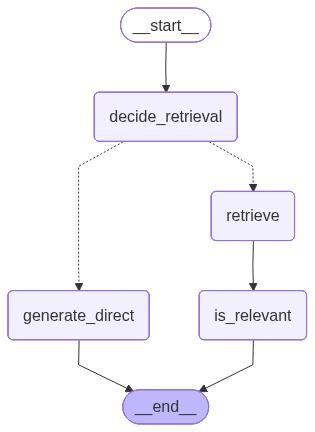

In [63]:
graph = StateGraph(SelfRAGState)
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('retrieve', retrieve)
graph.add_node('generate_direct', generate_direct)
graph.add_node('is_relevant', is_relevant)

graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', decision)

graph.add_edge('retrieve', 'is_relevant')
graph.add_edge('is_relevant', END)
graph.add_edge( 'generate_direct', END)

workflow= graph.compile()
workflow

In [64]:
result = workflow.invoke(
    {
        "question": "Who is the CEO NEXA AI",
        "decide_retrievalFlag": False,
        "docs": [],
        "answer": "",
    }
)
print(result["decide_retrievalFlag"])
#print(result["answer"])

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


True


In [65]:
test = model_structured.invoke(
    decisionPrompt.format_messages(question="What is Machine Learning?")
)
print(test)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


shouldRetrieve=False


In [66]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
****************************************************************************************************
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

****************************************************************************************************
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

****************************************************************************************************
Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
****************************************************************************************************


In [67]:
print(len(result['relevant_docs']))
print(len(result['docs']))
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

4
4
NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
****************************************************************************************************
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

****************************************************************************************************
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

****************************************************************************************************
Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
****************************************************************************************************


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
